# Analisi dei Multipli Bancari — Banche Italiane
**Obiettivo:** valutare se i multipli di mercato (P/E e P/B) riflettano correttamente la redditività delle principali banche italiane quotate, misurata tramite il ROTE (Return on Tangible Equity).

Il campione include **7 banche** nel periodo **2022–2024**, suddivise in tre cluster: banche tradizionali, gestori di risparmio e Mediobanca.

## Setup

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import statsmodels.api as sm
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.5,
    "figure.dpi": 120,
})

In [2]:
GROUPS = {
    "Banche tradizionali": {
        "banks": ["UniCredit", "Banco BPM", "Intesa Sanpaolo"],
        "color": "#2166ac",
        "marker": "o",
    },
    "Gestori di risparmio": {
        "banks": ["FinecoBank", "Banca Mediolanum", "Banca Generali"],
        "color": "#d6604d",
        "marker": "s",
    },
    "Mediobanca": {
        "banks": ["Mediobanca"],
        "color": "#4dac26",
        "marker": "D",
    },
}

def bank_color(name):
    for g in GROUPS.values():
        if name in g["banks"]:
            return g["color"]
    return "#7f7f7f"

def bank_marker(name):
    for g in GROUPS.values():
        if name in g["banks"]:
            return g["marker"]
    return "o" 

## Caricamento Dati

In [3]:
df = pd.read_csv("Dati Banche.csv")
df.columns = df.columns.str.strip()
df = df.rename(columns={"P/BV": "P/B"})
print(f"Loaded {len(df)} observations, {df['Anno'].nunique()} years, {df['Banca'].nunique()} banks")
df.head(14)

Loaded 42 observations, 6 years, 7 banks


,Banca,ROTE,P/B,P/E,EPS,EPS Growth,Anno
0,FinecoBank,0.233800,5.1,23.1,0.67,NaN,2022
1,Banca Generali,0.278100,3.6,15.1,2.12,NaN,2022
2,Banca Mediolanum,0.190900,2.0,11.0,0.71,NaN,2022
3,Mediobanca,0.088600,0.7,7.9,1.05,NaN,2022
4,Intesa Sanpaolo,0.100000,0.7,9.0,0.23,NaN,2022
5,UniCredit,0.094300,0.4,5.3,2.50,NaN,2022
6,Banco BPM,0.069400,0.4,7.2,0.46,NaN,2022
7,FinecoBank,0.321429,3.8,14.0,0.97,0.447761,2023
8,Banca Generali,0.316667,3.3,12.0,2.80,0.320755,2023
9,Banca Mediolanum,0.246753,1.8,7.7,1.11,0.563380,2023


In [4]:
def scatter_regression(ax, x, y, nomi, xlabel, ylabel, title, show_labels=True):
    for xi, yi, nome in zip(x, y, nomi):
        ax.scatter(xi, yi, color=bank_color(nome), marker=bank_marker(nome),
                   edgecolors="white", s=90, linewidth=0.8, alpha=0.85, zorder=3)
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min() * 0.95, x.max() * 1.05, 200)
    ax.plot(x_line, m * x_line + b, color="black", linestyle="--", linewidth=1.8,
            label=f"y = {m:.2f}x + {b:.2f}", zorder=2)
    y_hat = m * x + b
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    ax.text(0.97, 0.05, f"R² = {r2:.3f}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="lightgray", alpha=0.8))
    if show_labels:
        already_labeled = {}
        for xi, yi, nome in zip(x, y, nomi):
            offset_y = already_labeled.get(nome, 0)
            ax.annotate(nome, (xi, yi), textcoords="offset points",
                        xytext=(6, 3 + offset_y * 8), fontsize=7, color=bank_color(nome), alpha=0.75)
            already_labeled[nome] = already_labeled.get(nome, 0) + 1
    legend_handles = [Patch(facecolor=g["color"], edgecolor="white", label=label)
                      for label, g in GROUPS.items()]
    legend_handles.append(plt.Line2D([0], [0], color="black", linestyle="--",
                                      linewidth=1.8, label="Regressione lineare"))
    ax.legend(handles=legend_handles, fontsize=9, frameon=True, framealpha=0.9)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=10)
    return m, b, r2

def gap_table(df, x_col, y_col, m, b, label):
    df = df.copy()
    df[f"{label} atteso"] = m * df[x_col] + b
    df["Gap"] = df[y_col] - df[f"{label} atteso"]
    summary = df.groupby("Banca").agg(
        ROTE_medio=(x_col, "mean"),
        **{f"{label} medio": (y_col, "mean"),
           f"{label} atteso": (f"{label} atteso", "mean"),
           "Gap medio": ("Gap", "mean")}
    ).reset_index().sort_values("Gap medio", ascending=False)
    summary["Giudizio"] = summary["Gap medio"].apply(
        lambda v: "Sopravvalutata" if v > 0.2 else ("Sottovalutata" if v < -0.2 else "Equa"))
    return summary

## Figura 1 — P/E e P/B vs ROTE

La regressione lineare mette in luce due dinamiche distinte:

- **P/B vs ROTE** (R² ≈ 0.76): la relazione è robusta. Il mercato prezza in modo coerente la redditività tangibile — ogni punto percentuale di ROTE aggiuntivo si traduce in un incremento atteso di ~0.09x nel P/B. I gestori di risparmio (arancione), con ROTE strutturalmente più elevati, si collocano nella fascia alta del grafico, mentre le banche tradizionali (blu) si raggruppano in basso a sinistra.

- **P/E vs ROTE** (R² ≈ 0.46): la correlazione è più debole. Il P/E incorpora aspettative di crescita degli utili e fattori non catturati dal ROTE, come la qualità del business mix o la visibilità dei ricavi commissionali. Mediobanca (verde) risulta storicamente a sconto rispetto ai gestori puri, nonostante la progressiva evoluzione verso il Wealth Management.

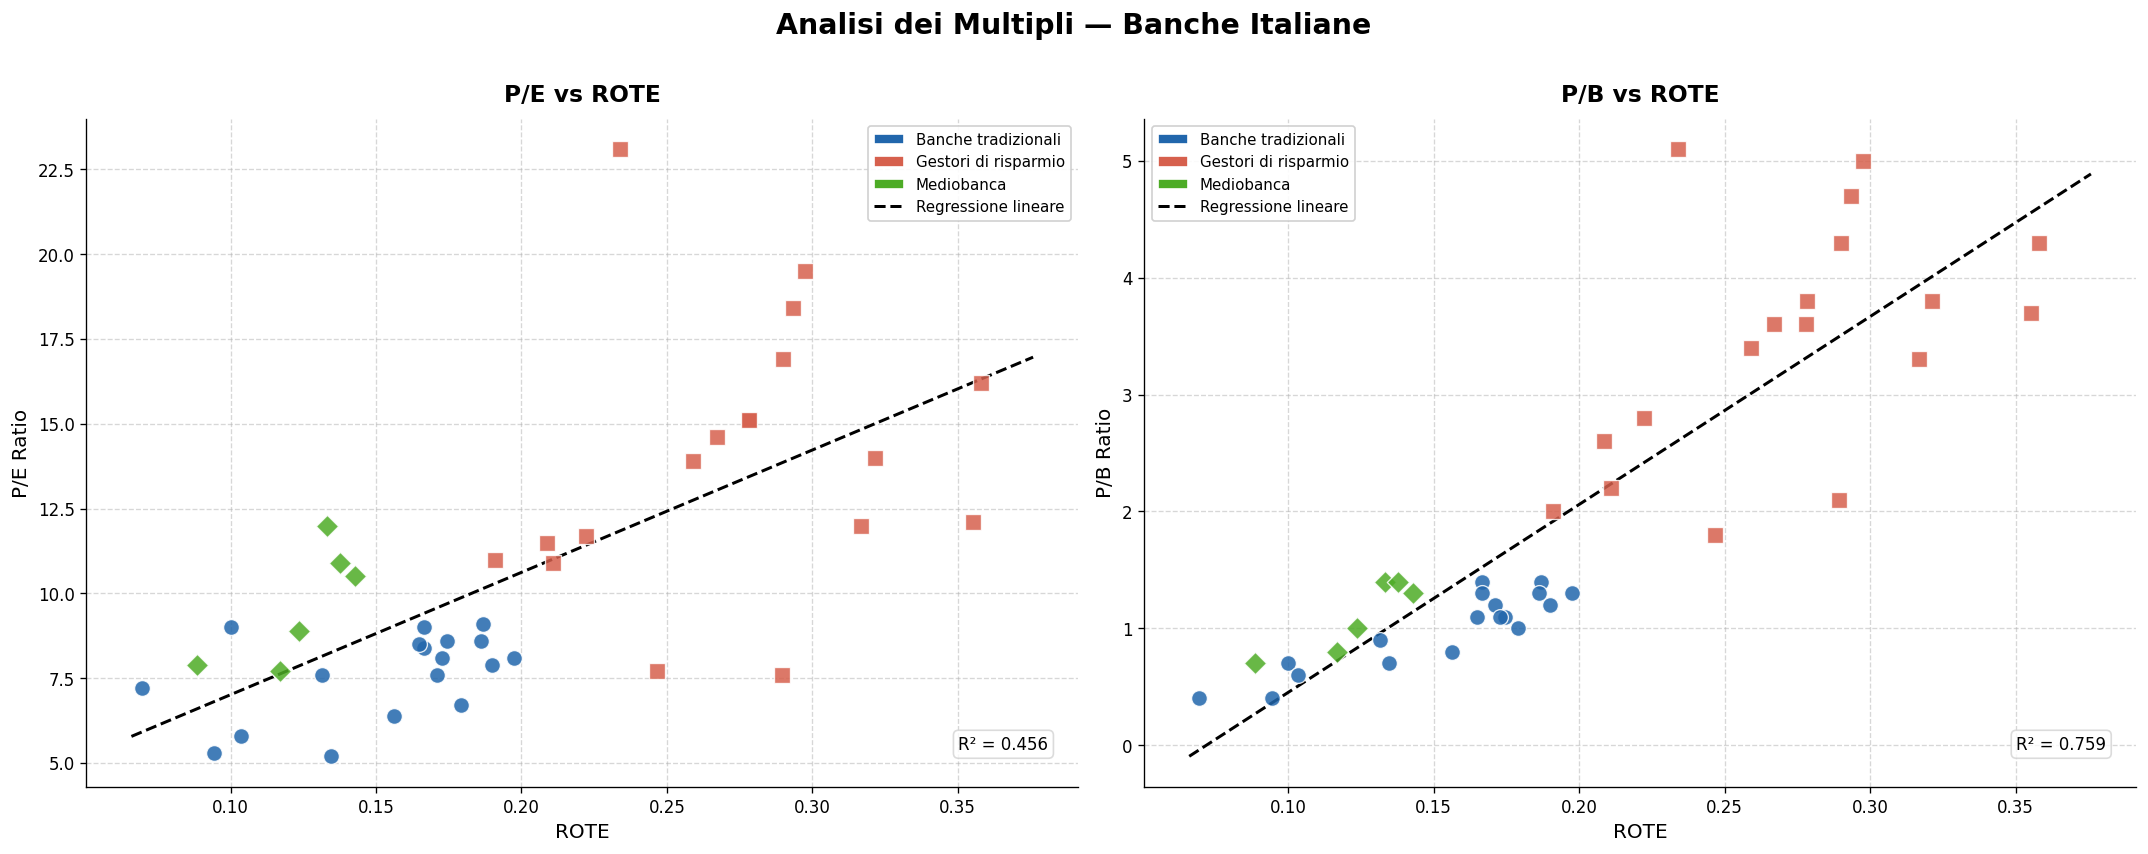

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Analisi dei Multipli — Banche Italiane", fontsize=17, fontweight="bold", y=1.01)

m_pe, b_pe, r2_pe = scatter_regression(
    axes[0], x=df["ROTE"], y=df["P/E"], nomi=df["Banca"],
    xlabel="ROTE", ylabel="P/E Ratio", title="P/E vs ROTE",
    show_labels=False)

m_pb, b_pb, r2_pb = scatter_regression(
    axes[1], x=df["ROTE"], y=df["P/B"], nomi=df["Banca"],
    xlabel="ROTE", ylabel="P/B Ratio", title="P/B vs ROTE",
    show_labels=False)

plt.tight_layout()
plt.savefig("scatter_multipli.png", bbox_inches="tight", dpi=150)
plt.show()

## Figura 2 — Gap di Valutazione

Il gap misura la differenza tra il multiplo osservato e quello atteso dalla regressione dato il ROTE della banca.

- Un **gap positivo** (rosso) indica che il mercato premia la banca oltre quanto giustificato dalla sola redditività — segnale di qualità percepita del business model, bassa rischiosità o crescita attesa degli utili.
- Un **gap negativo** (blu) segnala un potenziale sconto strutturale, che può riflettere incertezze strategiche, rischio percepito o semplicemente un modello di business meno apprezzato dal mercato.

**FinecoBank** si conferma la più sopravvalutata in termini di P/B, coerente con la sua reputazione di piattaforma digitale ad alta efficienza. **Mediobanca** mostra un gap negativo contenuto sul P/B, suggerendo che il mercato non abbia ancora pienamente incorporato la sua transizione verso il Wealth Management.

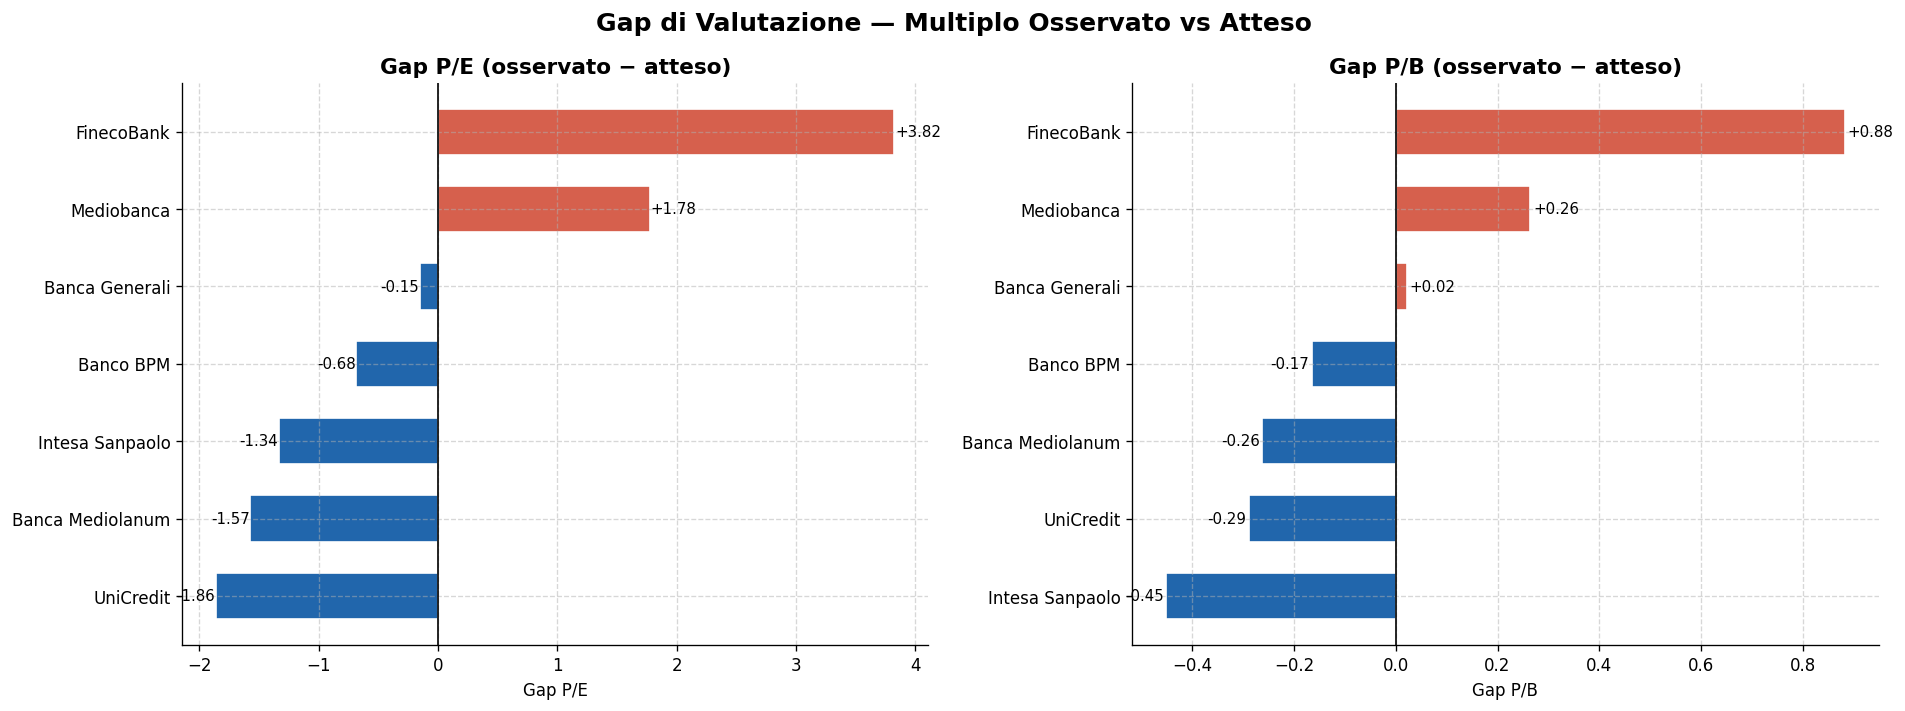

In [6]:
gap_pe = gap_table(df, "ROTE", "P/E", m_pe, b_pe, "P/E")
gap_pb = gap_table(df, "ROTE", "P/B", m_pb, b_pb, "P/B")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Gap di Valutazione — Multiplo Osservato vs Atteso", fontsize=15, fontweight="bold")

for ax, gap_df, label in [(axes[0], gap_pe, "P/E"), (axes[1], gap_pb, "P/B")]:
    colors = ["#d6604d" if v > 0 else "#2166ac" for v in gap_df["Gap medio"]]
    bars = ax.barh(gap_df["Banca"], gap_df["Gap medio"], color=colors, edgecolor="white", height=0.6)
    ax.axvline(0, color="black", linewidth=1.0)
    for bar, val in zip(bars, gap_df["Gap medio"]):
        ax.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
                f"{val:+.2f}", va="center", ha="left" if val >= 0 else "right", fontsize=9)
    ax.set_title(f"Gap {label} (osservato − atteso)", fontsize=13, fontweight="bold")
    ax.set_xlabel(f"Gap {label}")
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig("gap_valutazione.png", bbox_inches="tight", dpi=150)
plt.show()

## Figura 3 — Evoluzione dei Multipli per Banca (2022–2024)

L'analisi temporale permette di distinguere trend strutturali da oscillazioni di breve periodo.

- I **gestori di risparmio** (FinecoBank, Banca Generali, Banca Mediolanum) mostrano multipli P/B stabili o in lieve crescita, confermando la solidità dei loro modelli fee-based, meno esposti alla ciclicità dei tassi.
- Le **banche tradizionali** (UniCredit, Intesa, Banco BPM) hanno beneficiato del rialzo dei tassi nel 2022–2023, con un recupero dei multipli P/E, ma restano strutturalmente a sconto sul P/B.
- **Mediobanca** mostra un percorso di graduale rivalutazione del P/B (da 0.7x a 1.0x), coerente con la crescita dell'area Wealth Management e il miglioramento del ROTE.

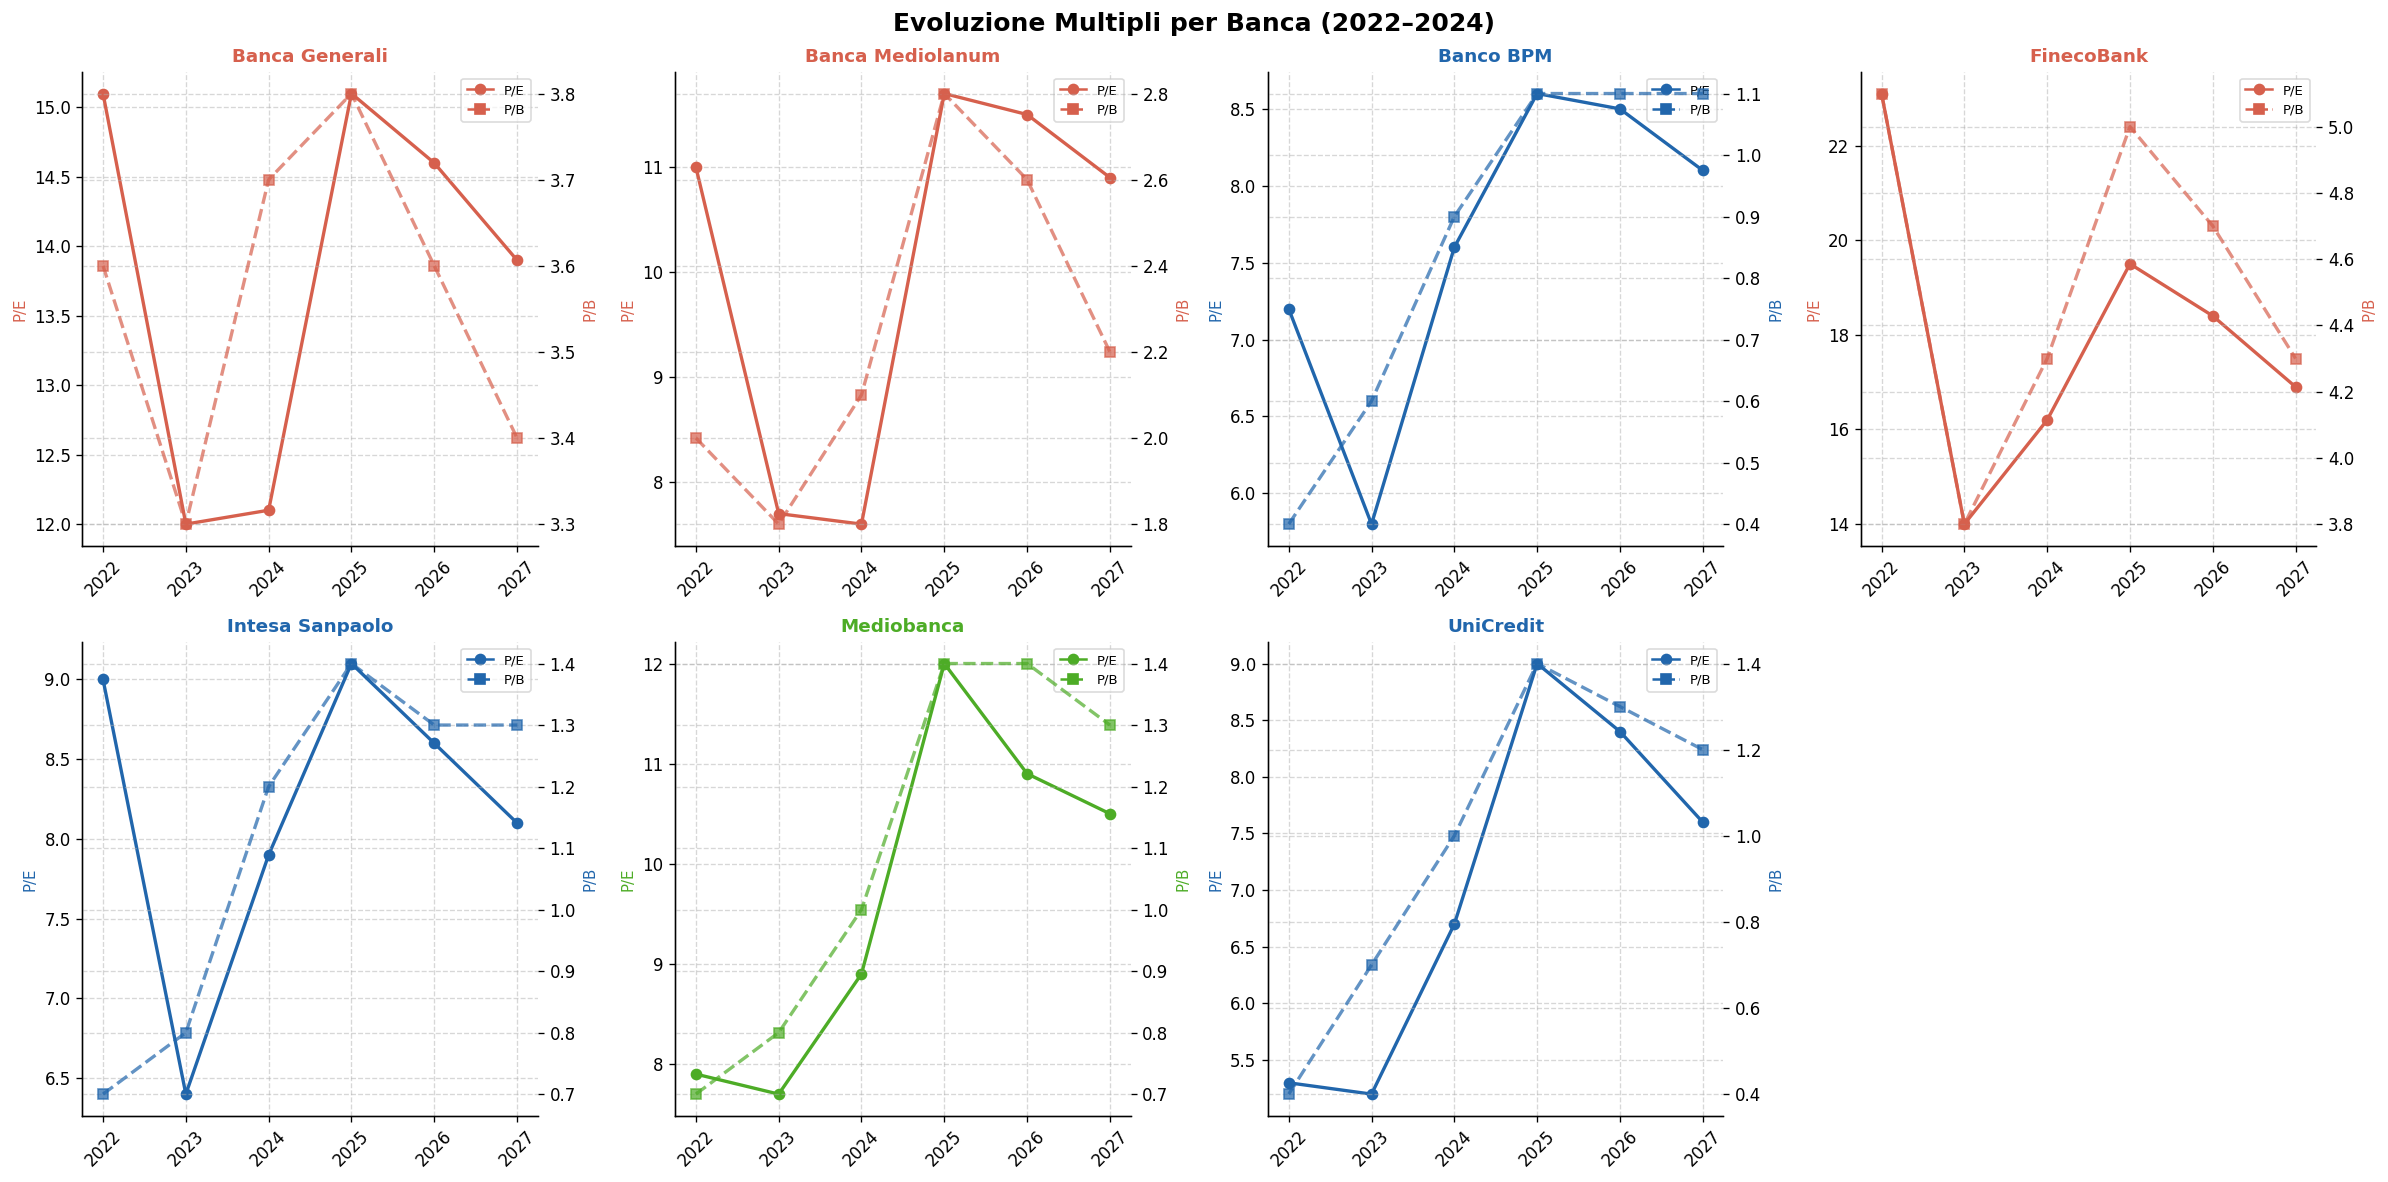

In [7]:
banks = sorted(df["Banca"].unique())
n = len(banks)
fig, axes = plt.subplots(2, n // 2 + n % 2, figsize=(20, 10), sharey=False)
axes = axes.flatten()
fig.suptitle("Evoluzione Multipli per Banca (2022–2024)", fontsize=15, fontweight="bold")

for i, bank in enumerate(banks):
    sub = df[df["Banca"] == bank].sort_values("Anno")
    ax = axes[i]
    ax2 = ax.twinx()
    color = bank_color(bank)
    ax.plot(sub["Anno"], sub["P/E"], color=color, marker="o", linewidth=2, label="P/E")
    ax2.plot(sub["Anno"], sub["P/B"], color=color, marker="s", linestyle="--",
             linewidth=2, alpha=0.7, label="P/B")
    ax.set_title(bank, fontsize=11, fontweight="bold", color=color)
    ax.set_ylabel("P/E", fontsize=9, color=color)
    ax2.set_ylabel("P/B", fontsize=9, color=color)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticks(sub["Anno"])
    lines = [plt.Line2D([0], [0], color=color, marker="o", label="P/E"),
             plt.Line2D([0], [0], color=color, marker="s", linestyle="--", label="P/B")]
    ax.legend(handles=lines, fontsize=8, framealpha=0.7)

for j in range(len(banks), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig("trend_multipli.png", bbox_inches="tight", dpi=150)
plt.show()

## Tabelle Gap & Regressione OLS

Le tabelle riepilogative mostrano, per ciascuna banca, il ROTE medio, il multiplo medio osservato, quello atteso dal modello e il gap risultante. La regressione OLS fornisce i parametri statistici completi (coefficienti, p-value, R²) per validare la robustezza della relazione lineare.

In [8]:
print("=" * 60)
print("  GAP DI VALUTAZIONE — P/E")
print("=" * 60)
print(gap_pe.to_string(index=False, float_format="{:.3f}".format))

print()
print("=" * 60)
print("  GAP DI VALUTAZIONE — P/B")
print("=" * 60)
print(gap_pb.to_string(index=False, float_format="{:.3f}".format))

rote_test = 0.20
print(f"\n{'='*60}")
print(f"  PREVISIONE per ROTE = {rote_test:.0%}")
print(f"{'='*60}")
print(f"  P/E atteso : {m_pe * rote_test + b_pe:.2f}")
print(f"  P/B atteso : {m_pb * rote_test + b_pb:.2f}")

  GAP DI VALUTAZIONE — P/E
           Banca  ROTE_medio  P/E medio  P/E atteso  Gap medio       Giudizio
      FinecoBank       0.299     18.017      14.192      3.825 Sopravvalutata
      Mediobanca       0.124      9.650       7.874      1.776 Sopravvalutata
  Banca Generali       0.292     13.800      13.953     -0.153           Equa
       Banco BPM       0.136      7.633       8.316     -0.682  Sottovalutata
 Intesa Sanpaolo       0.169      8.183       9.518     -1.335  Sottovalutata
Banca Mediolanum       0.228     10.067      11.637     -1.571  Sottovalutata
       UniCredit       0.152      7.033       8.893     -1.859  Sottovalutata

  GAP DI VALUTAZIONE — P/B
           Banca  ROTE_medio  P/B medio  P/B atteso  Gap medio       Giudizio
      FinecoBank       0.299      4.533       3.651      0.882 Sopravvalutata
      Mediobanca       0.124      1.100       0.835      0.265 Sopravvalutata
  Banca Generali       0.292      3.567       3.545      0.022           Equa
       Ba

In [9]:
X = sm.add_constant(df["ROTE"])
print("OLS — P/E ~ ROTE")
print(sm.OLS(df["P/E"], X).fit().summary())
print()
print("OLS — P/B ~ ROTE")
print(sm.OLS(df["P/B"], X).fit().summary())

OLS — P/E ~ ROTE
                            OLS Regression Results                            
Dep. Variable:                    P/E   R-squared:                       0.456
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     33.57
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           9.21e-07
Time:                        15:37:15   Log-Likelihood:                -105.21
No. Observations:                  42   AIC:                             214.4
Df Residuals:                      40   BIC:                             217.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.4090      1.331   

## Conclusioni

L'analisi conferma che il **ROTE è il principale driver di valutazione** per le banche italiane, con una capacità esplicativa significativamente più alta sul P/B (R² ≈ 0.76) rispetto al P/E (R² ≈ 0.46).

Il mercato riconosce strutturalmente un **premio ai gestori di risparmio** rispetto alle banche tradizionali, giustificato da:
- Modelli di business capital-light e fee-based, meno sensibili al ciclo dei tassi
- Maggiore visibilità e ricorrenza dei ricavi commissionali
- ROTE strutturalmente più elevati e stabili nel tempo

**Mediobanca** si trova in una posizione ibrida: il suo ROTE è in crescita ma ancora inferiore ai gestori puri, e il mercato la sconta leggermente rispetto ai peer. L'acquisizione di Banca Generali, se ben eseguita, potrebbe colmare questo gap riposizionando il gruppo verso multipli più in linea con il segmento Wealth Management.